In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.gridspec as gridspec


# Style global
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# Formateur roupies
def fmt_inr(x, _=None):
    return f"₹{x:,.0f}".replace(",", " ")

In [52]:
clean_data = pd.read_csv("Clean_Dataset.csv", index_col=0)
print(f"Données brutes : {clean_data.shape[0]:,} lignes × {clean_data.shape[1]} colonnes")

clean_data = clean_data.drop(columns=["flight", "arrival_time"])

clean_data = clean_data[clean_data["stops"] != "two_or_more"].copy()
print(f"Après suppression 2+ stops : {clean_data.shape[0]:,} lignes")

DESTINATIONS = ["Chennai", "Mumbai", "Delhi"]
df = clean_data[(clean_data["source_city"] == "Bangalore") &
         (clean_data["destination_city"].isin(DESTINATIONS))].copy()
print(f"Routes Bangalore→{{Mumbai,Delhi,Chennai}} : {df.shape[0]:,} lignes")
print()
df.info()

Données brutes : 300,153 lignes × 11 colonnes
Après suppression 2+ stops : 286,867 lignes
Routes Bangalore→{Mumbai,Delhi,Chennai} : 32,111 lignes

<class 'pandas.core.frame.DataFrame'>
Index: 32111 entries, 84065 to 261280
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline           32111 non-null  object 
 1   source_city       32111 non-null  object 
 2   departure_time    32111 non-null  object 
 3   stops             32111 non-null  object 
 4   destination_city  32111 non-null  object 
 5   class             32111 non-null  object 
 6   duration          32111 non-null  float64
 7   days_left         32111 non-null  int64  
 8   price             32111 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 2.4+ MB


In [53]:
# Vérification doublons et valeurs manquantes
df = df.drop_duplicates()
print("Doublons restants :", df.duplicated().sum())

df.isna().sum()

Doublons restants : 0


airline             0
source_city         0
departure_time      0
stops               0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

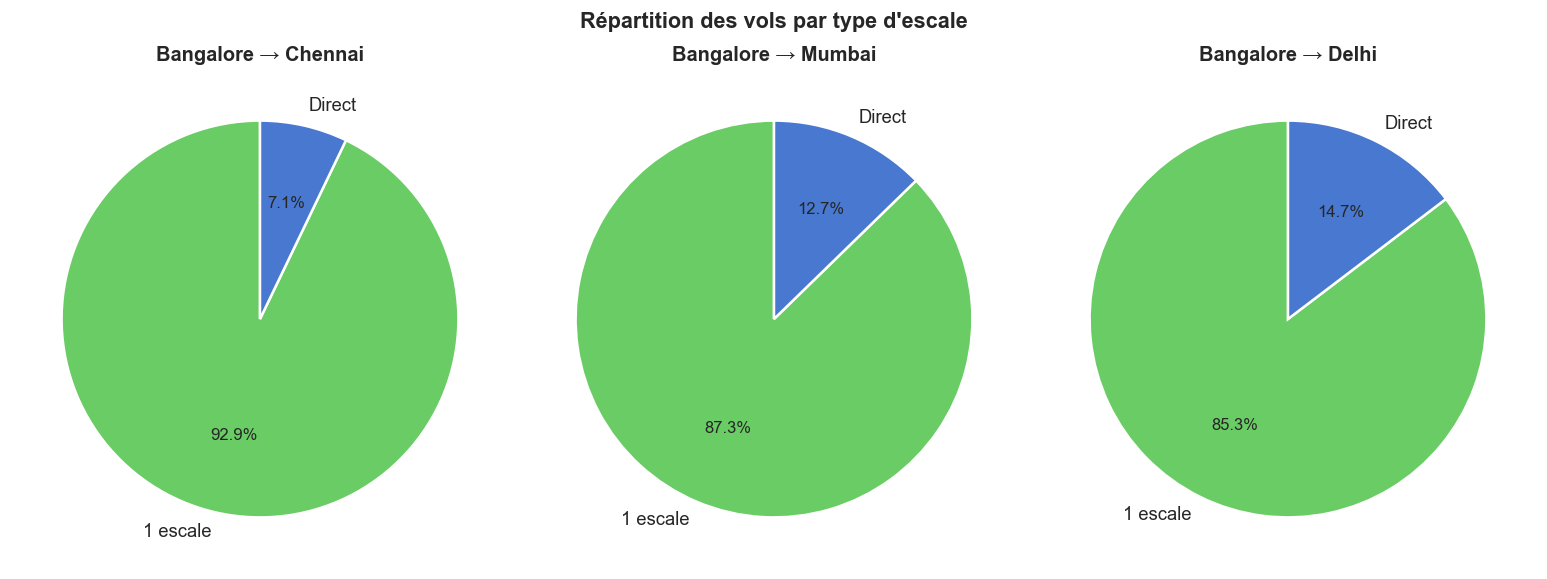

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, dest in zip(axes, DESTINATIONS):
    counts = df[df["destination_city"] == dest]["stops"].value_counts()
    labels = ["Direct" if s == "zero" else "1 escale" for s in counts.index]
    ax.pie(counts, labels=labels, autopct="%1.1f%%",
           colors=["#6ACC65", "#4878CF"],
           startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    ax.set_title(f"Bangalore → {dest}", fontweight="bold")

fig.suptitle("Répartition des vols par type d'escale", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Engineering

On crée des variables dérivées utiles pour les modèles et l'EDA :

In [55]:
time_order = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
time_enc   = {t: i for i, t in enumerate(time_order)}
df["departure_time_enc"] = df["departure_time"].map(time_enc)

df["est_direct"] = (df["stops"] == "zero").astype(int)

df["log_days_left"] = np.log1p(df["days_left"])
df["log_price"]     = np.log(df["price"])

df["prix_par_heure"] = df["price"] / df["duration"]

bins  = [0, 7, 15, 30, 50]
labels = ["Dernière minute (≤7j)", "Court terme (8-15j)", "Moyen terme (16-30j)", "Anticipé (31j+)"]
df["fenetre_reservation"] = pd.cut(df["days_left"], bins=bins, labels=labels, right=True)

Economy  = df[df["class"] == "Economy"].copy()
Business = df[df["class"] == "Business"].copy()

print(f"Economy  : {len(Economy):,} lignes")
print(f"Business : {len(Business):,} lignes")
Economy[["days_left", "log_days_left", "price", "log_price",
          "prix_par_heure", "est_direct", "departure_time_enc",
          "fenetre_reservation"]].describe().round(2)

Economy  : 21,523 lignes
Business : 10,128 lignes


,days_left,log_days_left,price,log_price,prix_par_heure,est_direct,departure_time_enc
count,21523.00,21523.00,21523.00,21523.00,21523.00,21523.00,21523.00
mean,26.07,3.11,6334.89,8.62,862.09,0.14,1.70
std,13.62,0.71,3491.72,0.50,705.53,0.35,1.44
min,1.00,0.69,1603.00,7.38,124.07,0.00,0.00
25%,15.00,2.77,4111.00,8.32,402.82,0.00,0.00
50%,26.00,3.30,5179.00,8.55,627.41,0.00,1.00
75%,38.00,3.66,7484.00,8.92,1109.33,0.00,3.00
max,49.00,3.91,40354.00,10.61,8327.00,1.00,5.00


## Analyse exploratoire (EDA)
### Distributions des variables numériques

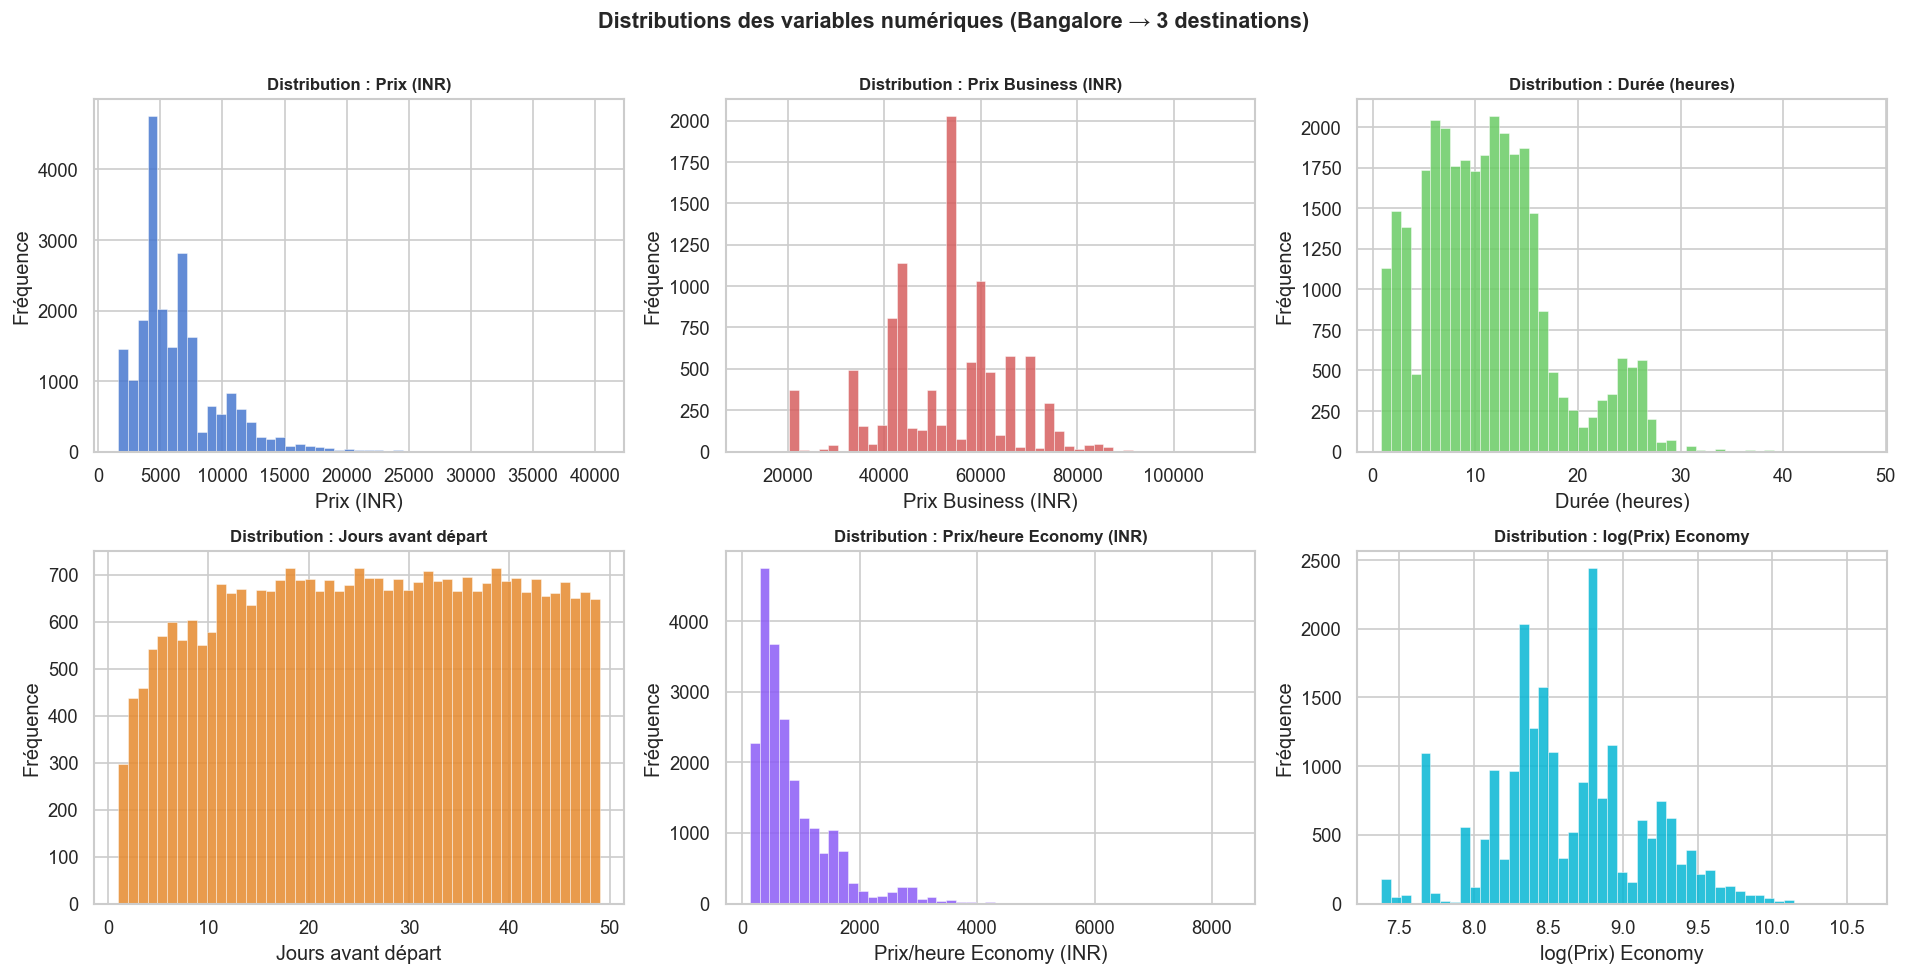

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

vars_info = [
    ("price",         Economy,  "#4878CF", "Prix (INR)"),
    ("price",         Business, "#D65F5F", "Prix Business (INR)"),
    ("duration",      df,       "#6ACC65", "Durée (heures)"),
    ("days_left",     df,       "#E68A2E", "Jours avant départ"),
    ("prix_par_heure",Economy,  "#8B5CF6", "Prix/heure Economy (INR)"),
    ("log_price",     Economy,  "#06B6D4", "log(Prix) Economy"),
]

for ax, (col, data, color, label) in zip(axes.flat, vars_info):
    ax.hist(data[col].dropna(), bins=49, color=color, edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.set_title(f"Distribution : {label}", fontsize=10, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Fréquence")

fig.suptitle("Distributions des variables numériques (Bangalore → 3 destinations)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Prix médian par compagnie et classe

C:\Users\user\AppData\Local\Temp\ipykernel_45660\3086273884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="airline", y="price", order=order,
C:\Users\user\AppData\Local\Temp\ipykernel_45660\3086273884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="airline", y="price", order=order,


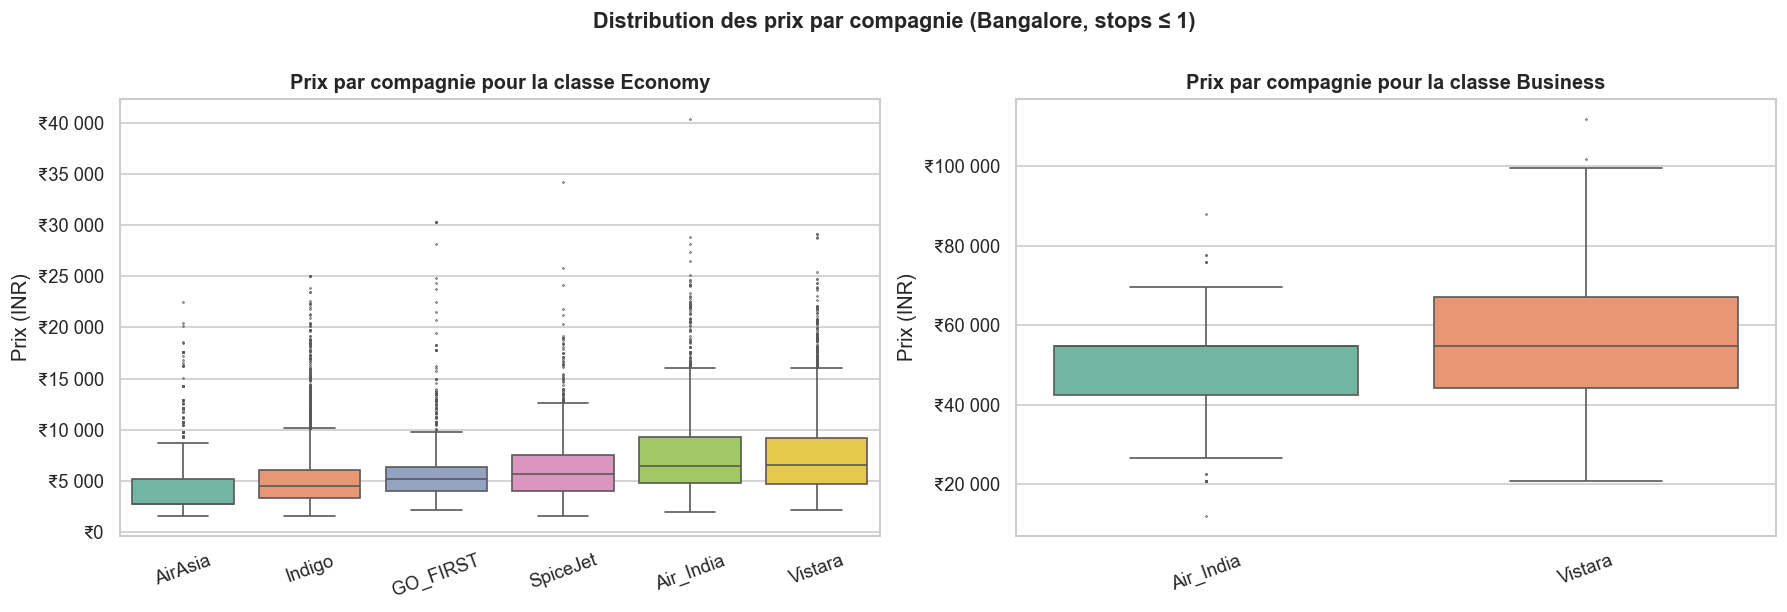

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    order = data.groupby("airline")["price"].median().sort_values().index
    sns.boxplot(data=data, x="airline", y="price", order=order,
                palette="Set2", ax=ax, flierprops=dict(marker=".", ms=1))
    ax.set_title(f"Prix par compagnie pour la classe {cls}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Prix (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Distribution des prix par compagnie (Bangalore, stops ≤ 1)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Prix par fenêtre de réservation

C:\Users\user\AppData\Local\Temp\ipykernel_45660\3858271067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="fenetre_reservation", y="price",
C:\Users\user\AppData\Local\Temp\ipykernel_45660\3858271067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="fenetre_reservation", y="price",


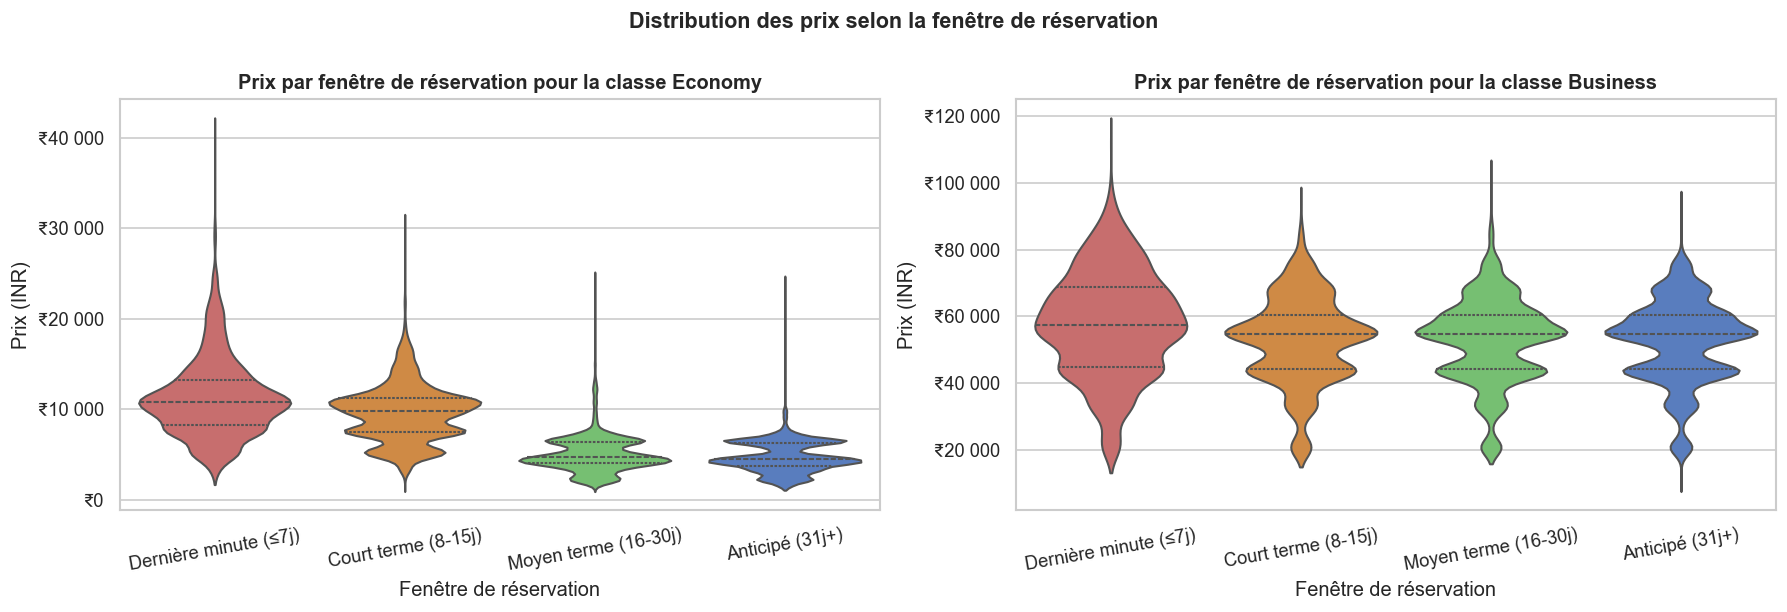

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    sns.violinplot(data=data, x="fenetre_reservation", y="price",
                   palette=["#D65F5F", "#E68A2E", "#6ACC65", "#4878CF"],
                   inner="quartile", ax=ax)
    ax.set_title(f"Prix par fenêtre de réservation pour la classe {cls}", fontweight="bold")
    ax.set_xlabel("Fenêtre de réservation")
    ax.set_ylabel("Prix (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Distribution des prix selon la fenêtre de réservation",
             fontsize=13, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

### Effet des escales sur le prix

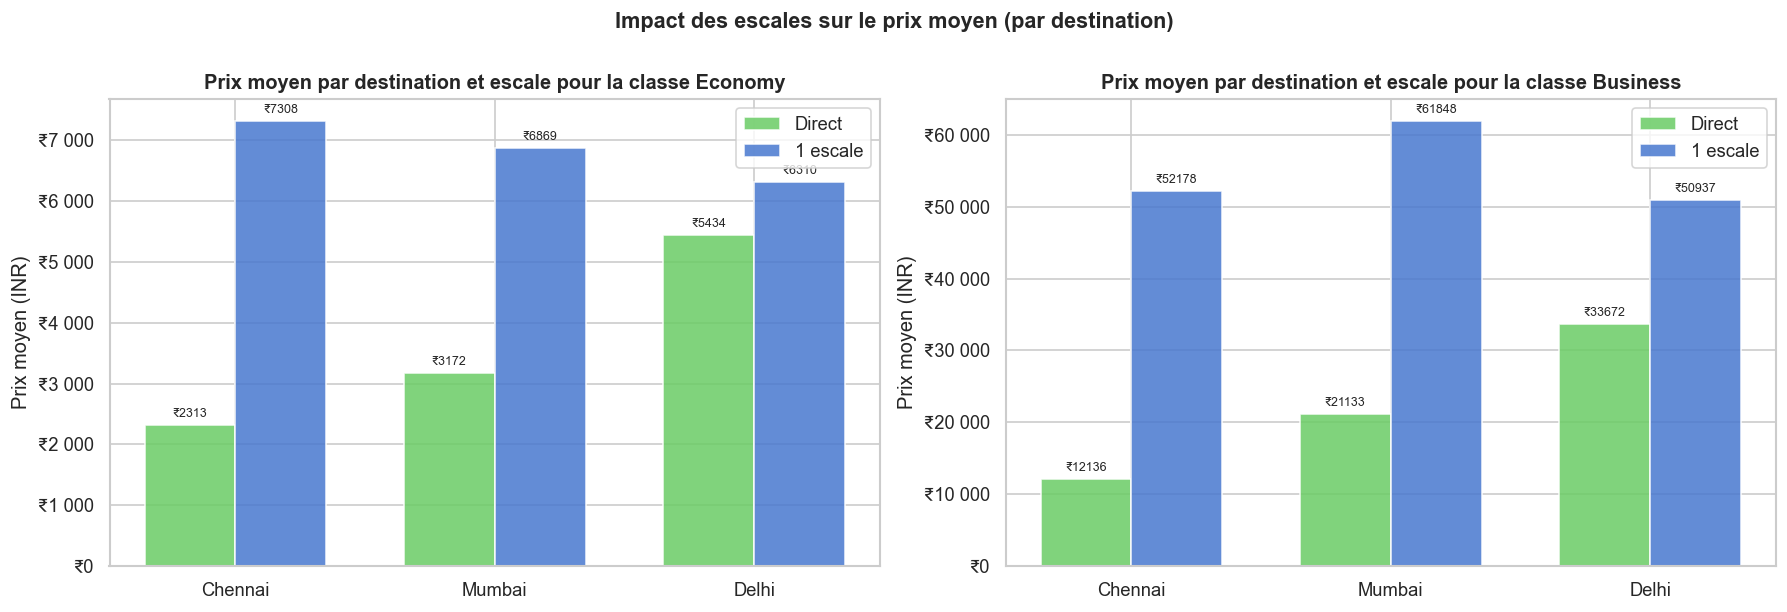

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(DESTINATIONS))
width = 0.35

for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    for i, (stop, label, color) in enumerate([("zero", "Direct", "#6ACC65"), ("one", "1 escale", "#4878CF")]):
        means = [data[(data["destination_city"] == dest) & (data["stops"] == stop)]["price"].mean()
                 for dest in DESTINATIONS]
        bars = ax.bar(x + i * width - width / 2, means, width,
                      label=label, color=color, alpha=0.85, edgecolor="white")
        ax.bar_label(bars, fmt="₹%.0f", padding=3, fontsize=7.5)

    ax.set_title(f"Prix moyen par destination et escale pour la classe {cls}", fontweight="bold")
    ax.set_ylabel("Prix moyen (INR)")
    ax.set_xticks(x)
    ax.set_xticklabels(DESTINATIONS)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.legend()

plt.suptitle("Impact des escales sur le prix moyen (par destination)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Prix selon l'heure de départ

C:\Users\user\AppData\Local\Temp\ipykernel_45660\2599253364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="departure_time", y="price",
C:\Users\user\AppData\Local\Temp\ipykernel_45660\2599253364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="departure_time", y="price",


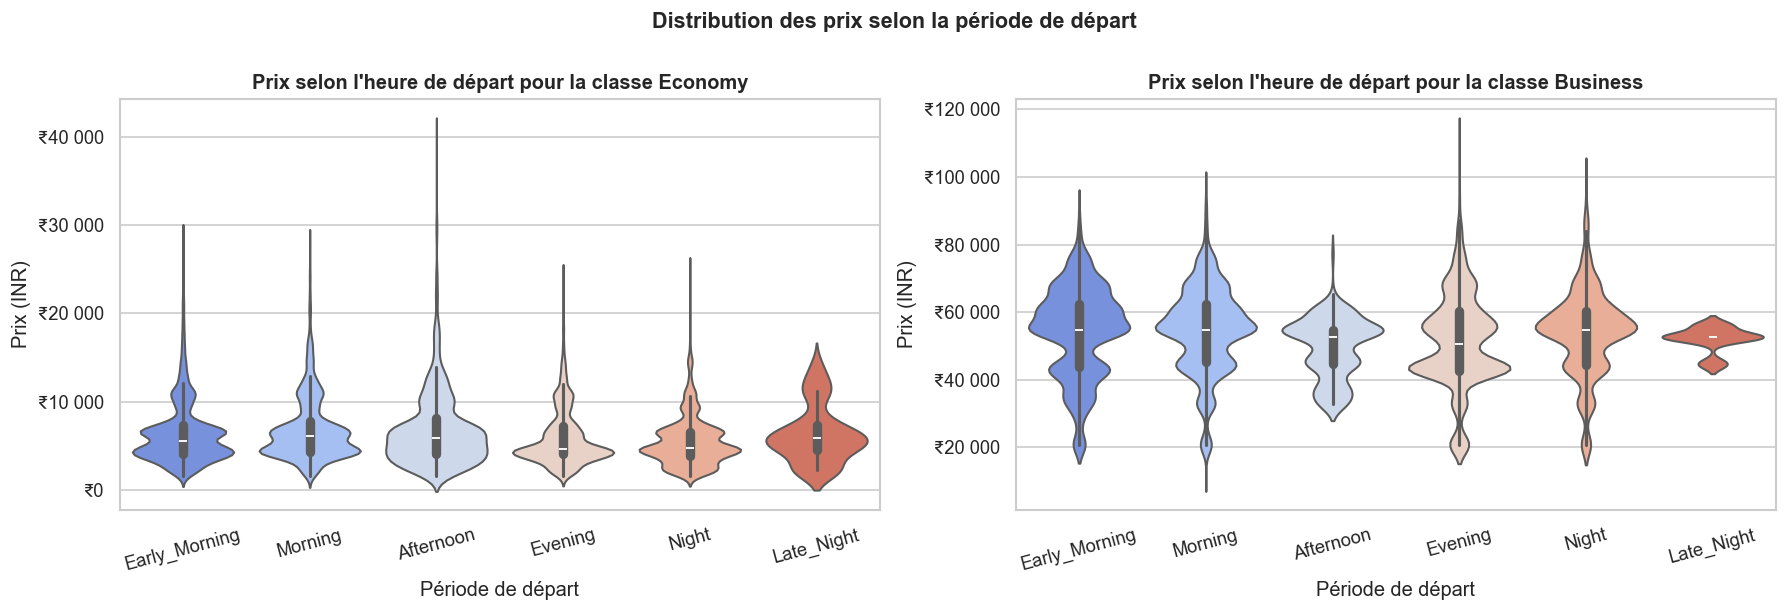

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    sns.violinplot(data=data, x="departure_time", y="price",
                   order=time_order, palette="coolwarm", inner="box", ax=ax)
    ax.set_title(f"Prix selon l'heure de départ pour la classe {cls}", fontweight="bold")
    ax.set_xlabel("Période de départ")
    ax.set_ylabel("Prix (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Distribution des prix selon la période de départ",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.6 Matrice de corrélation

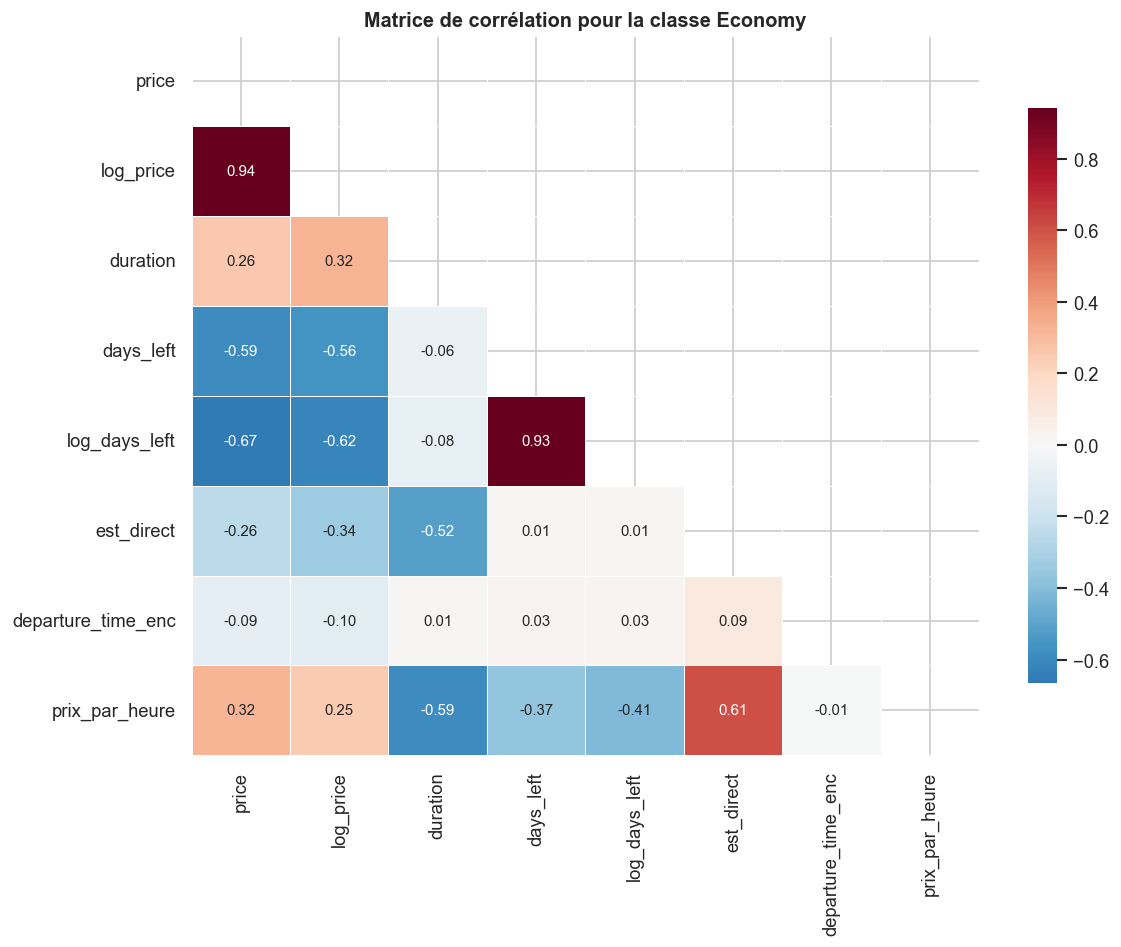

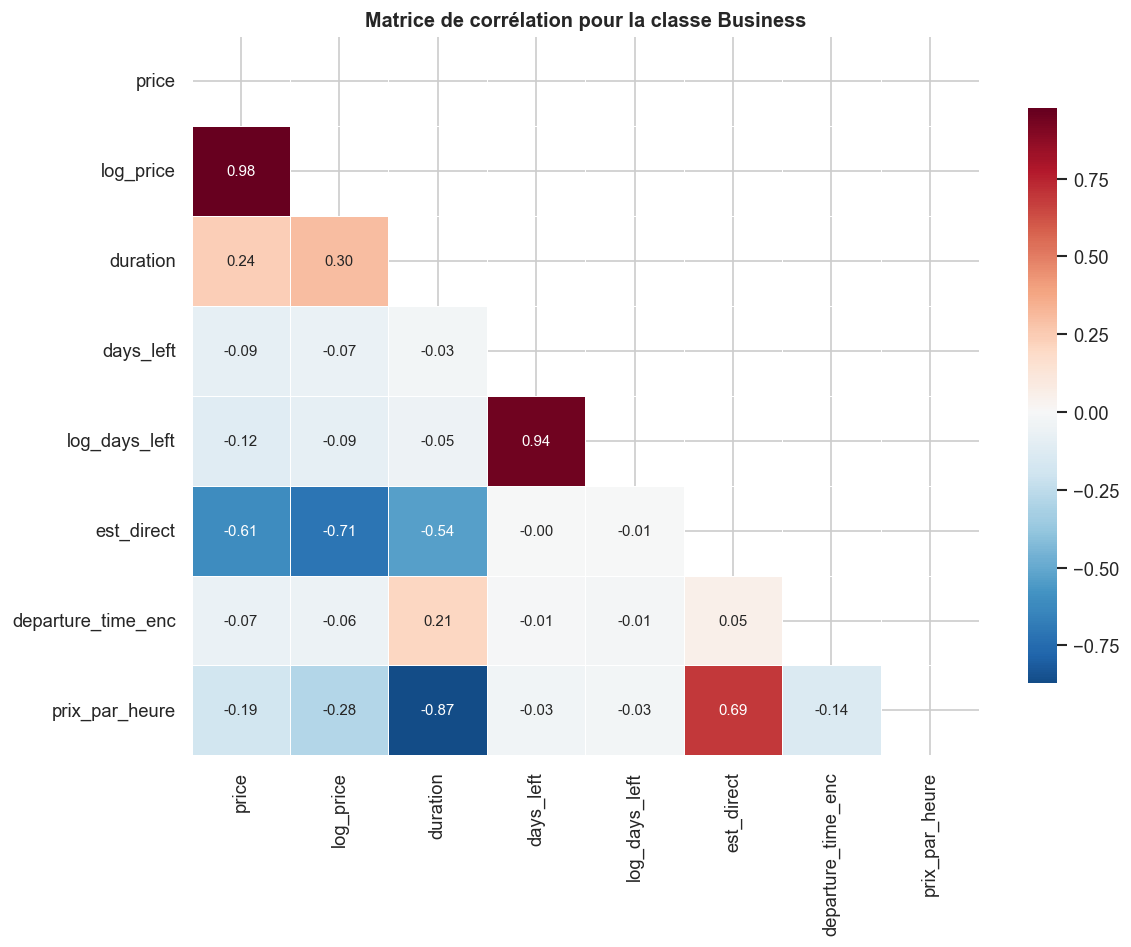

In [61]:
num_cols = ["price", "log_price", "duration", "days_left", "log_days_left",
             "est_direct", "departure_time_enc", "prix_par_heure"]

for cls, data in [("Economy", Economy), ("Business", Business)]:
    corr = data[num_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, linewidths=0.4, ax=ax,
                annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
    ax.set_title(f"Matrice de corrélation pour la classe {cls}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Prix vs Days Left pour 3 destinations, Direct vs 1 escale

Graphique central du projet : évolution du prix médian selon `days_left`,  
**par destination** et **par type de vol** (direct ou 1 escale).

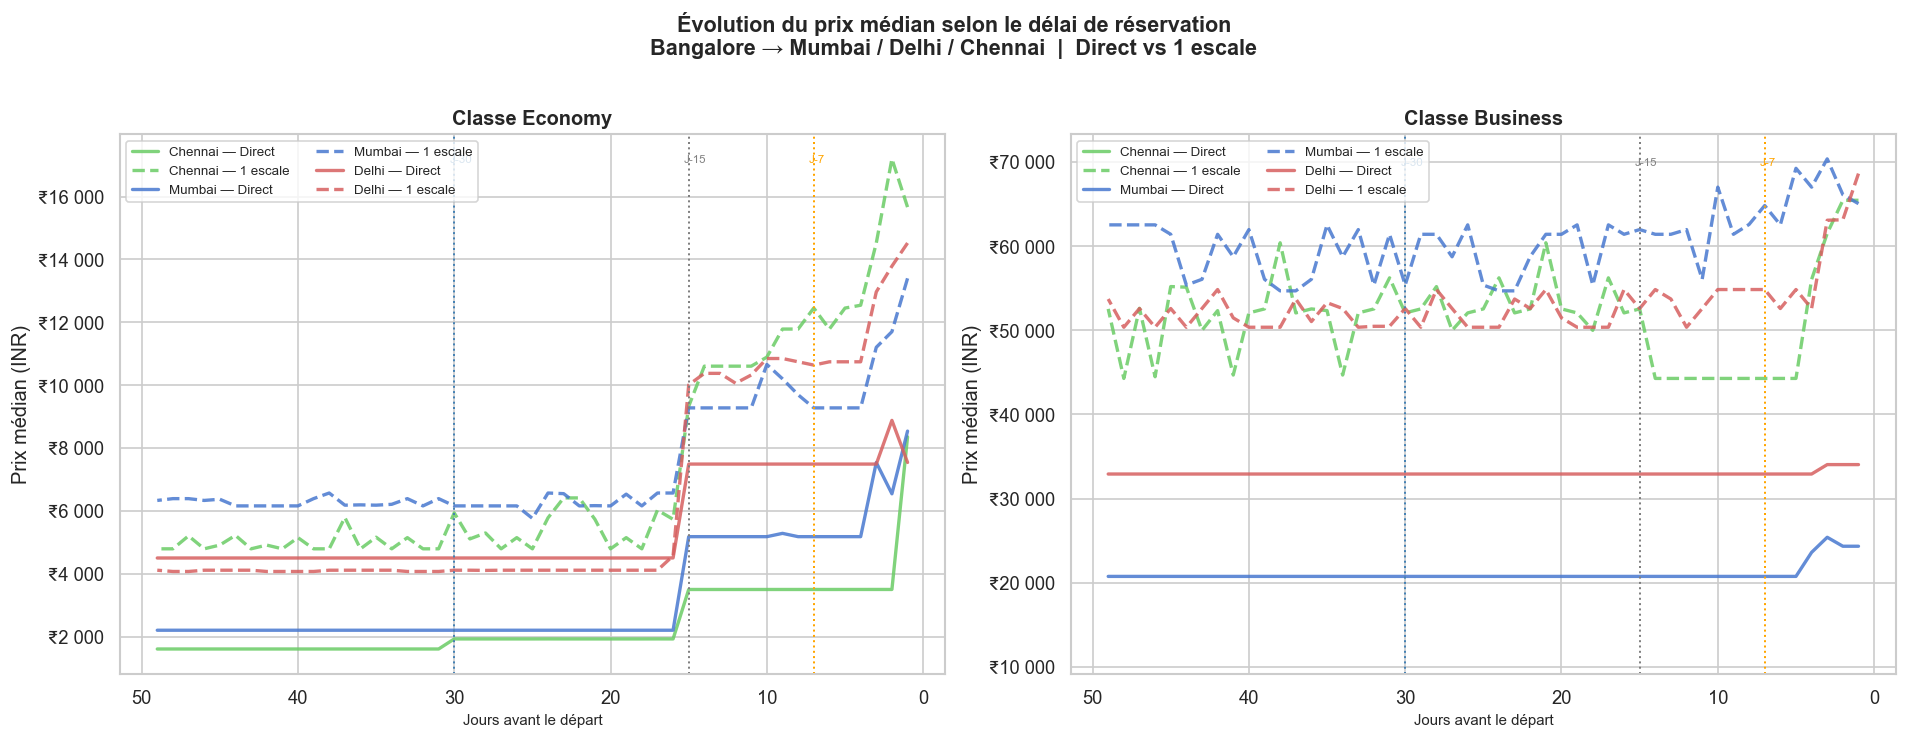

In [62]:
DEST_COLORS = {
    "Mumbai" : "#4878CF",
    "Delhi"  : "#D65F5F",
    "Chennai": "#6ACC65",
}
STOPS_LS = {"zero": "-", "one": "--"}
STOPS_LAB = {"zero": "Direct", "one": "1 escale"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, cls in zip(axes, ["Economy", "Business"]):
    data = df[df["class"] == cls]
    for dest in DESTINATIONS:
        for stop in ["zero", "one"]:
            sub = (data[(data["destination_city"] == dest) & (data["stops"] == stop)]
                   .groupby("days_left")["price"].median().reset_index().sort_values("days_left"))
            if sub.empty:
                continue
            ax.plot(sub["days_left"], sub["price"],
                    color=DEST_COLORS[dest],
                    linestyle=STOPS_LS[stop],
                    lw=2, alpha=0.85,
                    label=f"{dest} — {STOPS_LAB[stop]}")

    ax.invert_xaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_xlabel("Jours avant le départ", fontsize=9)
    ax.set_ylabel("Prix médian (INR)")
    ax.set_title(f"Classe {cls}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, ncol=2)

    # Seuils visuels
    for xv, lbl, col in [(7, "J-7", "orange"), (15, "J-15", "gray"), (30, "J-30", "steelblue")]:
        ax.axvline(x=xv, color=col, ls=":", lw=1.2)
        ax.text(xv+0.3, ax.get_ylim()[1]*0.95, lbl, fontsize=7, color=col)

fig.suptitle("Évolution du prix médian selon le délai de réservation\n"
             "Bangalore → Mumbai / Delhi / Chennai  |  Direct vs 1 escale",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Régression par morceaux (Piecewise Linear Regression)

### Identification des breakpoints

En observant les courbes, on identifie des ruptures de pente nettes autour de :
- **J-49 à J-31** : prix stables / légère tendance
- **J-30 à J-16** : légère hausse progressive
- **J-15** : **chute brutale** (seuil majeur)
- **J-8 à J-7** : remontée progressive
- **J-1 à J-7** : flambée dernière minute

On définit 4 segments (breakpoints : 7, 15, 30).

In [63]:
BREAKPOINTS = [7, 15, 30]

def piecewise_fit(days, prices, breakpoints):
    """
    Ajuste une régression linéaire par morceaux.
    Retourne les paramètres (pente, intercept) de chaque segment.
    """
    bps = [0] + sorted(breakpoints) + [days.max() + 1]
    segments = []
    for i in range(len(bps) - 1):
        lo, hi = bps[i], bps[i+1]
        mask = (days >= lo) & (days < hi)
        x_seg = days[mask].values.reshape(-1, 1)
        y_seg = prices[mask].values
        if len(x_seg) < 2:
            segments.append(None)
            continue
        reg = LinearRegression().fit(x_seg, y_seg)
        r2  = r2_score(y_seg, reg.predict(x_seg))
        segments.append({
            "lo": lo, "hi": hi,
            "coef": reg.coef_[0], "intercept": reg.intercept_,
            "r2": r2, "n": len(x_seg),
            "model": reg
        })
    return segments

print("Fonction piecewise_fit définie.")
print(f"Breakpoints : {BREAKPOINTS}  → {len(BREAKPOINTS)+1} segments")

Fonction piecewise_fit définie.
Breakpoints : [7, 15, 30]  → 4 segments


### Ajustement et visualisation pour la classe Economy

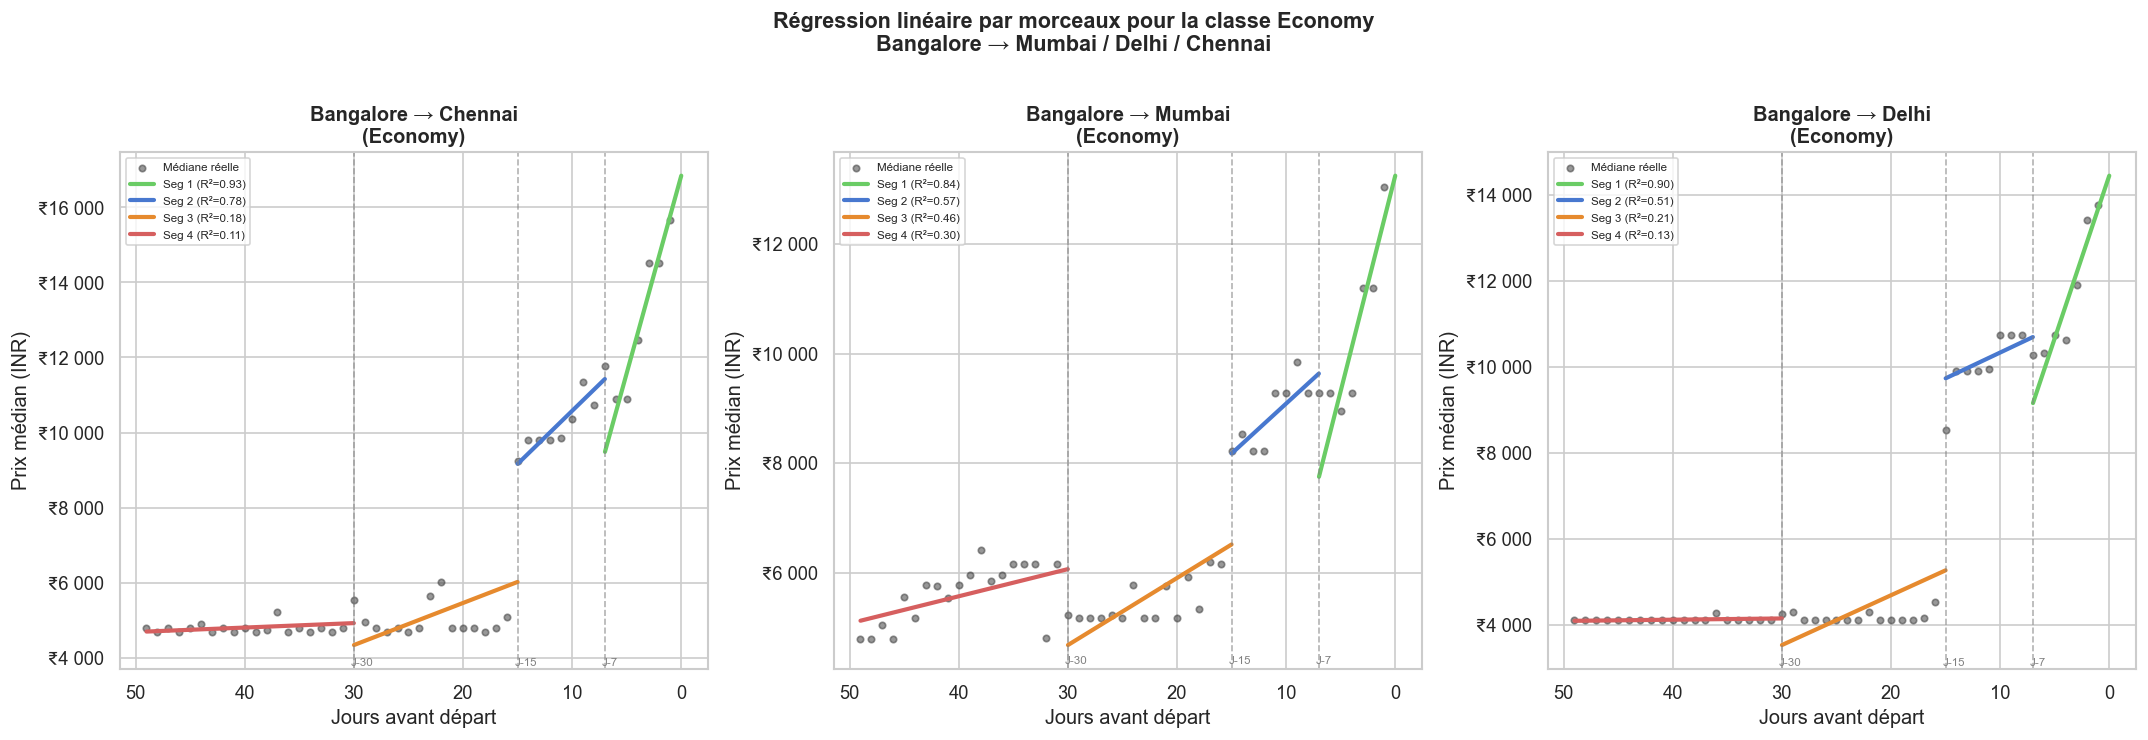

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

SEG_COLORS = ["#6ACC65", "#4878CF", "#E68A2E", "#D65F5F"]

results_eco = {}

for ax, dest in zip(axes, DESTINATIONS):
    sub = (Economy[Economy["destination_city"] == dest]
           .groupby("days_left")["price"].median().reset_index())
    sub = sub.sort_values("days_left")
    days   = sub["days_left"]
    prices = sub["price"]

    # Scatter des données
    ax.scatter(days, prices, s=15, color="#333", alpha=0.5, zorder=2, label="Médiane réelle")

    # Régression par morceaux
    segs = piecewise_fit(days, prices, BREAKPOINTS)
    results_eco[dest] = segs

    bps_all = [0] + sorted(BREAKPOINTS) + [days.max() + 1]
    for j, seg in enumerate(segs):
        if seg is None:
            continue
        x_plot = np.linspace(seg["lo"], min(seg["hi"] - 0.01, days.max()), 50)
        y_plot = seg["model"].predict(x_plot.reshape(-1, 1))
        ax.plot(x_plot, y_plot, color=SEG_COLORS[j % 4], lw=2.5,
                label=f"Seg {j+1} (R²={seg['r2']:.2f})")

    # Breakpoints
    for bp in BREAKPOINTS:
        ax.axvline(x=bp, color="gray", ls="--", lw=1, alpha=0.6)
        ax.text(bp + 0.3, ax.get_ylim()[0] * 1.02, f"J-{bp}",
                fontsize=7, color="gray")

    ax.invert_xaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_title(f"Bangalore → {dest}\n(Economy)", fontweight="bold")
    ax.set_xlabel("Jours avant départ")
    ax.set_ylabel("Prix médian (INR)")
    ax.legend(fontsize=7)

fig.suptitle("Régression linéaire par morceaux pour la classe Economy\nBangalore → Mumbai / Delhi / Chennai",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Coefficients des segments et interprétation

In [65]:
print("Résumé des pentes par segment (Economy)\n")
print(f"{'Route':<12} {'Segment':<10} {'Plage':<12} {'Pente/jour':>12} {'Intercept':>12} {'R²':>8} {'N':>6}")
print("-" * 72)

seg_labels = ["S1 (anticipé)", "S2 (moyen)", "S3 (court)", "S4 (dernière min)"]
bps_ranges = [(30, 49), (15, 30), (7, 15), (0, 7)]

for dest in DESTINATIONS:
    for j, seg in enumerate(results_eco[dest]):
        if seg is None:
            continue
        print(f"{dest:<12} {seg_labels[j]:<10} J{seg['lo']}-J{seg['hi']-1:<6} "
              f"{seg['coef']:>12.1f} {seg['intercept']:>12.1f} {seg['r2']:>8.3f} {seg['n']:>6}")
    print()

Résumé des pentes par segment (Economy)

Route        Segment    Plage          Pente/jour    Intercept       R²      N
------------------------------------------------------------------------
Chennai      S1 (anticipé) J0-J6           -1052.4      16842.5    0.933      6
Chennai      S2 (moyen) J7-J14           -282.9      13406.2    0.784      8
Chennai      S3 (court) J15-J29           -112.1       7702.3    0.183     15
Chennai      S4 (dernière min) J30-J49            -11.9       5280.3    0.112     20

Mumbai       S1 (anticipé) J0-J6            -786.7      13248.9    0.842      6
Mumbai       S2 (moyen) J7-J14           -182.7      10913.0    0.569      8
Mumbai       S3 (court) J15-J29           -122.5       8350.9    0.461     15
Mumbai       S4 (dernière min) J30-J49            -49.6       7551.0    0.295     20

Delhi        S1 (anticipé) J0-J6            -756.0      14440.4    0.898      6
Delhi        S2 (moyen) J7-J14           -120.0      11531.0    0.515      8
Delhi   

## Capture de la non-linéarité

### Transformations appliquées aux droites par morceaux

Les pentes des segments capturent des régimes linéaires locaux.  
Pour capturer la courbure globale (notamment la chute à J-15 et la remontée à J-7), on enrichit le modèle avec :
- **log(days_left + 1)** : compresse l'échelle pour les grandes valeurs
- **days_left²** : terme quadratique
- **Indicatrices de segment** (dummy variables) : intègrent les breakpoints

On compare 3 modèles : Linéaire simple, Polynomial degré 2, Log-transformé.

In [66]:
from sklearn.preprocessing import PolynomialFeatures

def build_segment_features(df_in, breakpoints=[7, 15, 30]):
    X = pd.DataFrame()
    X["days_left"]     = df_in["days_left"]
    X["log_days_left"] = np.log1p(df_in["days_left"])
    X["days_sq"]       = df_in["days_left"] ** 2
    # Hinge features (ReLU sur chaque breakpoint) — capture les coudes
    for bp in breakpoints:
        X[f"hinge_{bp}"] = np.maximum(0, df_in["days_left"] - bp)
    return X

print("Features enrichies :")
print(build_segment_features(Economy.head(3)).columns.tolist())

Features enrichies :
['days_left', 'log_days_left', 'days_sq', 'hinge_7', 'hinge_15', 'hinge_30']


log(prix) à d=50 : 7.3776  (log(1603) = 7.3796)


TypeError: iteration over a 0-d array

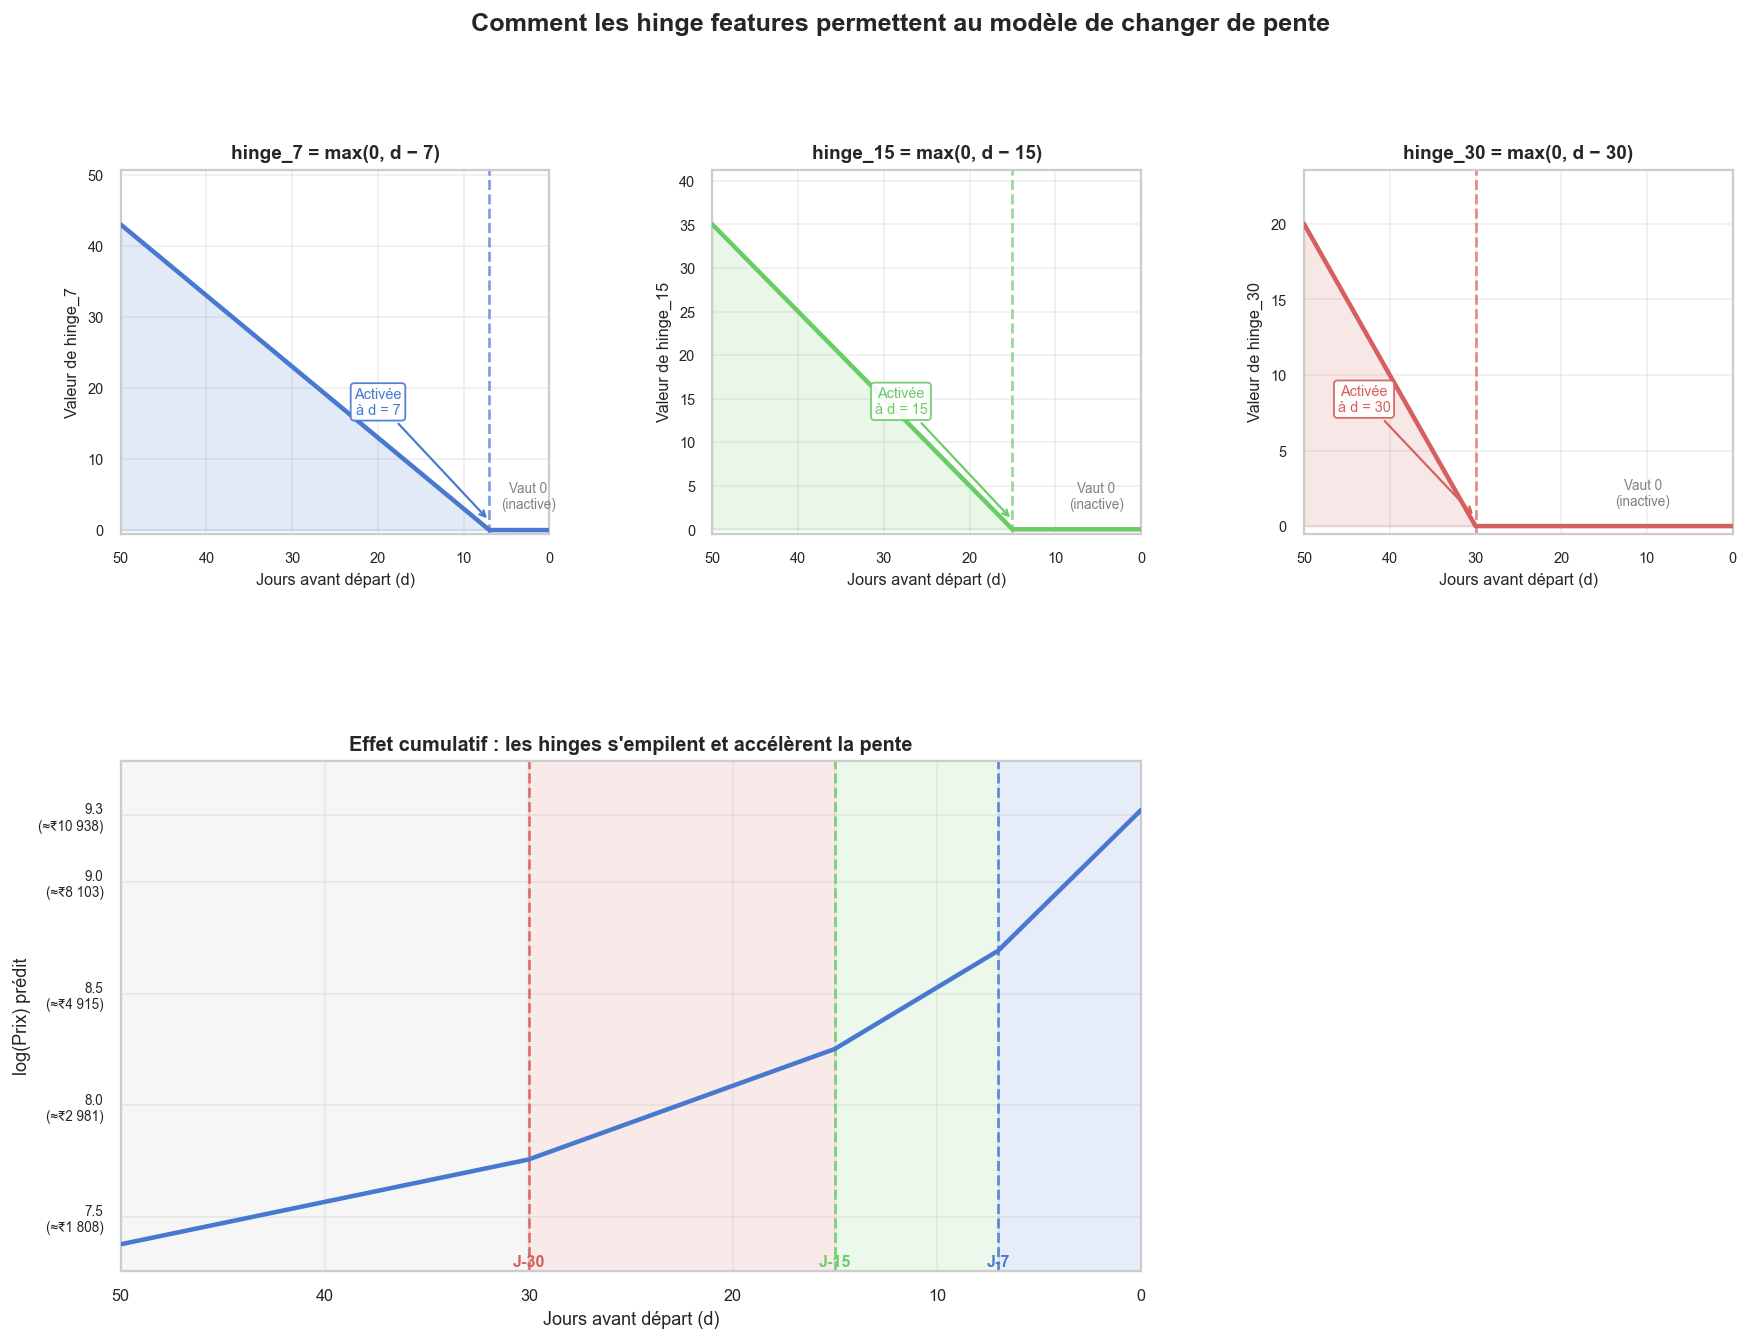

In [67]:
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

PRICE_MIN = 1603
PRICE_MAX = 11188
LOG_MIN = np.log(PRICE_MIN)   # ≈ 7.38
LOG_MAX = np.log(PRICE_MAX)   # ≈ 9.32

# d(log prix)/d(d) — négatif car le prix monte quand d diminue
# Plus d est petit (proche du départ), plus la pente est raide
s_lm   = -0.090   # d ≤ 7   (dernière minute, pente maximale)
s_ct   = -0.055   # 7 < d ≤ 15
s_mt   = -0.033   # 15 < d ≤ 30
s_ant  = -0.019   # d > 30  (anticipé, pente douce)

# Vérifions que l'étendue couvre bien [log(1603), log(11188)]
# À d=50: LOG_MAX + s_lm*7 + s_ct*8 + s_mt*15 + s_ant*20
check = LOG_MAX + s_lm*7 + s_ct*8 + s_mt*15 + s_ant*20
print(f"log(prix) à d=50 : {check:.4f}  (log(1603) = {LOG_MIN:.4f})")

def log_price_pw(d_arr):
    """Courbe log(prix) calculée par morceaux à partir de d=0."""
    d = np.asarray(d_arr, float)
    result = np.empty_like(d)
    for i, di in enumerate(d):
        v = LOG_MAX
        if di <= 7:
            v += s_lm * di
        elif di <= 15:
            v += s_lm * 7 + s_ct * (di - 7)
        elif di <= 30:
            v += s_lm * 7 + s_ct * 8 + s_mt * (di - 15)
        else:
            v += s_lm * 7 + s_ct * 8 + s_mt * 15 + s_ant * (di - 30)
        result[i] = v
    return result

d_range = np.linspace(0, 50, 1000)
y_model = log_price_pw(d_range)


C7   = '#4878CF'
C15  = '#6ACC65'
C30  = '#D65F5F'
CGRAY = '#888888'


fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('white')
fig.suptitle("Comment les hinge features permettent au modèle de changer de pente",
             fontsize=14, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       height_ratios=[1, 1.4],
                       hspace=0.52, wspace=0.38)


hinge_cfg = [
    (7,  C7,   'hinge_7',  'Valeur de hinge_7'),
    (15, C15,  'hinge_15', 'Valeur de hinge_15'),
    (30, C30,  'hinge_30', 'Valeur de hinge_30'),
]

for i, (bp, color, name, ylabel) in enumerate(hinge_cfg):
    ax = fig.add_subplot(gs[0, i])
    h_vals = np.maximum(0, d_range - bp)

    ax.plot(d_range, h_vals, color=color, lw=2.5, zorder=3)
    ax.fill_between(d_range, 0, h_vals, alpha=0.15, color=color, zorder=2)
    ax.axvline(x=bp, color=color, ls='--', lw=1.5, alpha=0.7)

    ax.set_xlim(50, 0)
    ax.set_ylim(-0.5, h_vals.max() * 1.18)
    ax.set_xlabel("Jours avant départ (d)", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(f"hinge_{bp} = max(0, d − {bp})", fontweight='bold', fontsize=10.5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

    hmax = h_vals.max()

    # Annotation "Activée à d = bp" — positionnée pour ne pas déborder
    offset_x = min(bp + 13, 46)
    offset_y = hmax * 0.38
    ax.annotate(f"Activée\nà d = {bp}",
                xy=(bp, hmax * 0.03),
                xytext=(offset_x, offset_y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                fontsize=8, color=color, ha='center',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=color, alpha=0.92))

    # "Vaut 0 (inactive)" dans la zone inactive (droite du breakpoint)
    inactive_x = max(bp * 0.35, 2)
    ax.text(inactive_x, hmax * 0.07, "Vaut 0\n(inactive)",
            fontsize=7.5, color='gray', ha='center')


ax_cum = fig.add_subplot(gs[1, :2])

y_lo = LOG_MIN - 0.12
y_hi = LOG_MAX + 0.22

# Zones colorées — ordre pour la légende
ax_cum.fill_between(d_range, y_lo, y_hi,
                    where=(d_range <= 7),
                    alpha=0.13, color=C7,
                    label='Zone J-7 (3 hinges actives)')
ax_cum.fill_between(d_range, y_lo, y_hi,
                    where=((d_range > 7) & (d_range <= 15)),
                    alpha=0.13, color=C15,
                    label='Zone J-15 (2 hinges actives)')
ax_cum.fill_between(d_range, y_lo, y_hi,
                    where=((d_range > 15) & (d_range <= 30)),
                    alpha=0.13, color=C30,
                    label='Zone J-30 (1 hinge active)')
ax_cum.fill_between(d_range, y_lo, y_hi,
                    where=(d_range > 30),
                    alpha=0.07, color=CGRAY,
                    label='Zone anticipée (aucune hinge)')

# Courbe du modèle
ax_cum.plot(d_range, y_model, color=C7, lw=2.5,
            label='Modèle piecewise + log', zorder=5)

# Lignes verticales aux breakpoints
for bp, color, lbl in [(30, C30, 'J-30'), (15, C15, 'J-15'), (7, C7, 'J-7')]:
    ax_cum.axvline(x=bp, color=color, ls='--', lw=1.5, alpha=0.85)
    ax_cum.text(bp, y_lo + 0.02, lbl,
                fontsize=9, color=color, ha='center', fontweight='bold')

ax_cum.set_xlim(50, 0)
ax_cum.set_ylim(y_lo, y_hi)
ax_cum.set_xlabel("Jours avant départ (d)", fontsize=10)
ax_cum.set_ylabel("log(Prix) prédit", fontsize=10)
ax_cum.set_title("Effet cumulatif : les hinges s'empilent et accélèrent la pente",
                 fontweight='bold', fontsize=11)
ax_cum.grid(True, alpha=0.3)
ax_cum.tick_params(labelsize=9)

# Y-axis : ticks avec prix approximatifs
yticks = [7.5, 8.0, 8.5, 9.0, 9.3]
ylabels = ['7.5\n(≈₹1 808)', '8.0\n(≈₹2 981)', '8.5\n(≈₹4 915)',
           '9.0\n(≈₹8 103)', '9.3\n(≈₹10 938)']
ax_cum.set_yticks(yticks)
ax_cum.set_yticklabels(ylabels, fontsize=7.5)


# Zone d > 30 (côté GAUCHE du plot, x inversé → d grand = gauche)
y40 = log_price_pw(40)
ax_cum.annotate("Pente = β₁\n(aucune hinge)",
                xy=(40, y40),
                xytext=(43, y40 + 0.27),
                arrowprops=dict(arrowstyle='->', color=CGRAY, lw=1.0),
                fontsize=9, color='#444', ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#aaa', alpha=0.95))

# Zone d ≤ 7 (côté DROIT du plot, prix le plus élevé)
# Boîte au centre du plot, flèche vers la courbe dans la zone J-7
y3 = log_price_pw(3)
ax_cum.annotate("Pente = β₁+β₃+β₄+β₅\n(3 hinges empilées)",
                xy=(3, y3),
                xytext=(17, y3 - 0.22),
                arrowprops=dict(arrowstyle='->', color=C7, lw=1.2,
                                connectionstyle='arc3,rad=-0.15'),
                fontsize=9, color=C7, ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=C7, alpha=0.95))

# Légende — ordre visuel logique, en bas à gauche
handles, labels = ax_cum.get_legend_handles_labels()
# Réordonner : modèle en premier
order = [4, 0, 1, 2, 3]  # modèle, J-7, J-15, J-30, anticipée
ax_cum.legend([handles[o] for o in order],
              [labels[o] for o in order],
              loc='lower left', fontsize=8.5, ncol=1,
              framealpha=0.93, edgecolor='#ccc')


ax_tab = fig.add_subplot(gs[1, 2])
ax_tab.axis('off')
ax_tab.set_title("Pentes effectives par zone",
                 fontweight='bold', fontsize=10.5, pad=10)

table_data = [
    ['d > 30',       'aucune',         'β₁'],
    ['15 < d ≤ 30',  'hinge_30',       'β₁ + β₅'],
    ['7 < d ≤ 15',   'hinge_30, 15',   'β₁ + β₅ + β₄'],
    ['d ≤ 7',        'toutes',         'β₁ + β₅ + β₄ + β₃'],
]
col_labels = ['Zone', 'Hinges actives', 'Pente sur d']

tbl = ax_tab.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0.0, 0.22, 1.0, 0.64]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)

# Header
for j in range(3):
    c = tbl[0, j]
    c.set_facecolor('#2c4770')
    c.set_text_props(color='white', fontweight='bold')
    c.set_height(0.19)

# Lignes alternées
row_fcs = ['#eef2ff', '#ffffff']
for i in range(1, 5):
    for j in range(3):
        c = tbl[i, j]
        c.set_facecolor(row_fcs[(i - 1) % 2])
        c.set_height(0.19)
    # Dernière ligne : colonne "pente" un peu plus petite
    tbl[i, 2].set_text_props(fontsize=8.0)

# Note de bas de tableau
ax_tab.text(0.5, 0.11,
            "Chaque hinge qui s'active\najoute une pente β supplémentaire.",
            ha='center', va='center', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#fffde7', edgecolor='#d4b800', alpha=0.92))

plt.show()

C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:

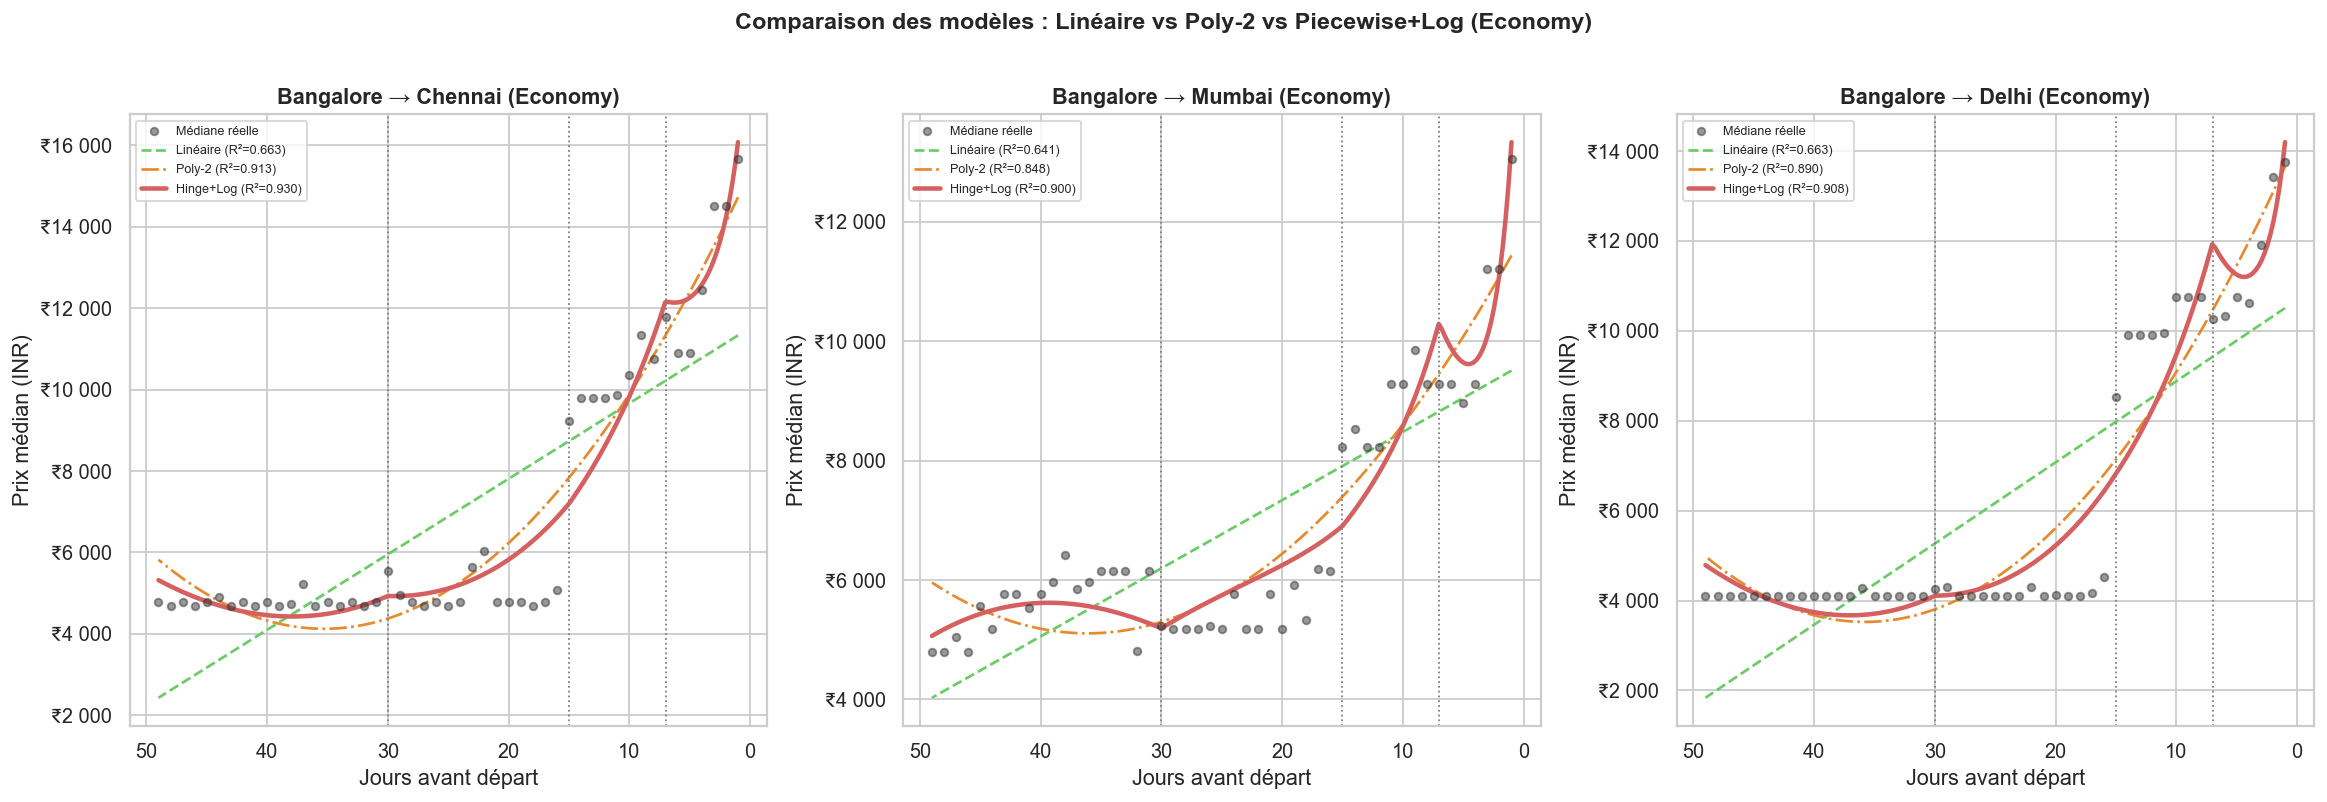

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, dest in zip(axes, DESTINATIONS):
    sub = (Economy[Economy["destination_city"] == dest]
           .groupby("days_left")["price"].median().reset_index()
           .sort_values("days_left"))

    X_base = sub[["days_left"]]
    X_enrich = build_segment_features(sub)
    y = sub["price"]
    x_plot = np.linspace(sub["days_left"].min(), sub["days_left"].max(), 200)

    # Modèle 1 : linéaire simple
    m1 = LinearRegression().fit(X_base, y)
    y1 = m1.predict(x_plot.reshape(-1, 1))

    # Modèle 2 : polynomial deg 2
    poly = PolynomialFeatures(degree=2, include_bias=False)
    Xp = poly.fit_transform(X_base)
    m2 = LinearRegression().fit(Xp, y)
    y2 = m2.predict(poly.transform(x_plot.reshape(-1, 1)))

    # Modèle 3 : enrichi (hinge + log)
    m3 = LinearRegression().fit(X_enrich, y)
    x_enrich_plot = build_segment_features(pd.DataFrame({"days_left": x_plot}))
    y3 = m3.predict(x_enrich_plot)

    # Scatter
    ax.scatter(sub["days_left"], y, s=18, color="#333", alpha=0.5, zorder=3, label="Médiane réelle")
    ax.plot(x_plot, y1, "--", color="#6ACC65", lw=1.5,
            label=f"Linéaire (R²={r2_score(y, m1.predict(X_base)):.3f})")
    ax.plot(x_plot, y2, "-.", color="#E68A2E", lw=1.5,
            label=f"Poly-2 (R²={r2_score(y, m2.predict(Xp)):.3f})")
    ax.plot(x_plot, y3, "-",  color="#D65F5F", lw=2.5,
            label=f"Hinge+Log (R²={r2_score(y, m3.predict(X_enrich)):.3f})")

    for bp in BREAKPOINTS:
        ax.axvline(x=bp, color="gray", ls=":", lw=1)

    ax.invert_xaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_title(f"Bangalore → {dest} (Economy)", fontweight="bold")
    ax.set_xlabel("Jours avant départ")
    ax.set_ylabel("Prix médian (INR)")
    ax.legend(fontsize=7)

fig.suptitle("Comparaison des modèles : Linéaire vs Poly-2 vs Piecewise+Log (Economy)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Résidus du meilleur modèle (Hinge+Log)

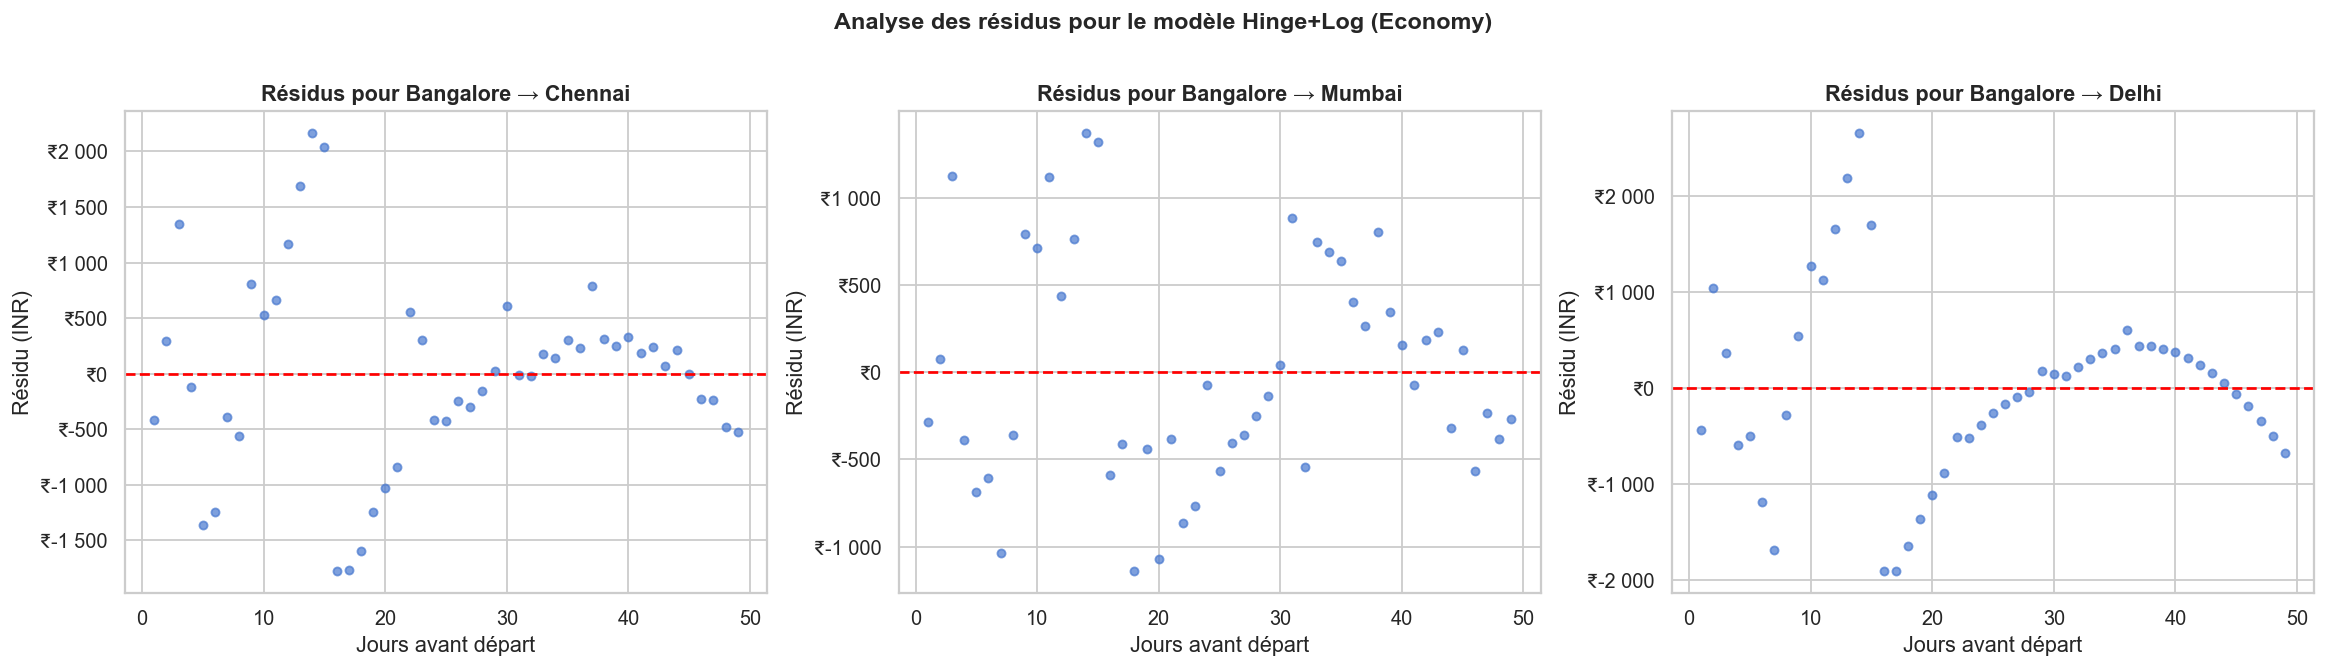

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, dest in zip(axes, DESTINATIONS):
    sub = (Economy[Economy["destination_city"] == dest]
           .groupby("days_left")["price"].median().reset_index()
           .sort_values("days_left"))
    X = build_segment_features(sub)
    y = sub["price"]
    m = LinearRegression().fit(X, y)
    resid = y - m.predict(X)

    ax.scatter(sub["days_left"], resid, s=20, color="#4878CF", alpha=0.7)
    ax.axhline(0, color="red", lw=1.5, ls="--")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_title(f"Résidus pour Bangalore → {dest}", fontweight="bold")
    ax.set_xlabel("Jours avant départ")
    ax.set_ylabel("Résidu (INR)")

fig.suptitle("Analyse des résidus pour le modèle Hinge+Log (Economy)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Prédiction du prix à J+2 (régression linéaire/multiple)

### Objectif
Se placer à un jour donné `d`, prédire le prix médian dans **2 jours** (à `d+2`).  
C'est une régression sur les données agrégées par `days_left`.

### Variables explicatives
- `days_left` (le jour d'observation)
- `est_direct` (type de vol)
- `destination_city` (encodée)
- Features hinge pour la non-linéarité

In [71]:
# Préparation du dataset de prédiction J+2 (Economy)
def build_prediction_dataset(data, horizon=2):
    """
    Pour chaque observation à days_left=d,
    on crée la cible = prix médian à days_left = d + horizon.
    """
    rows = []
    for dest in DESTINATIONS:
        for stop in ["zero", "one"]:
            sub = (data[(data["destination_city"] == dest) & (data["stops"] == stop)]
                   .groupby("days_left")["price"].median().reset_index()
                   .sort_values("days_left"))
            sub = sub.reset_index(drop=True)
            # Pour chaque point d, la cible est le prix à d+horizon
            for i in range(len(sub) - horizon):
                row = {
                    "days_left"     : sub.loc[i, "days_left"],
                    "price_now"     : sub.loc[i, "price"],
                    "price_target"  : sub.loc[i + horizon, "price"],
                    "destination"   : dest,
                    "est_direct"    : 1 if stop == "zero" else 0,
                }
                rows.append(row)
    return pd.DataFrame(rows)

pred_eco = build_prediction_dataset(Economy, horizon=2)
print(f"Dataset de prédiction J+2 (Economy) : {len(pred_eco):,} lignes")
pred_eco.head(10)

Dataset de prédiction J+2 (Economy) : 282 lignes


,days_left,price_now,price_target,destination,est_direct
0,1,8354.5,3499.0,Chennai,1
1,2,3498.5,3498.5,Chennai,1
2,3,3499.0,3498.5,Chennai,1
3,4,3498.5,3498.0,Chennai,1
4,5,3498.5,3498.5,Chennai,1
5,6,3498.0,3498.0,Chennai,1
6,7,3498.5,3498.0,Chennai,1
7,8,3498.0,3498.0,Chennai,1
8,9,3498.0,3498.0,Chennai,1
9,10,3498.0,3498.0,Chennai,1


In [72]:
# Encodage destination + features hinge
dest_dummies = pd.get_dummies(pred_eco["destination"], prefix="dest", dtype=int)
pred_eco = pd.concat([pred_eco, dest_dummies], axis=1)

# Features d'entrée
feat_cols = ["days_left", "est_direct"] + list(dest_dummies.columns)
# Ajout features hinge
for bp in BREAKPOINTS:
    col = f"hinge_{bp}"
    pred_eco[col] = np.maximum(0, pred_eco["days_left"] - bp)
    feat_cols.append(col)
pred_eco["log_days"] = np.log1p(pred_eco["days_left"])
feat_cols.append("log_days")

X = pred_eco[feat_cols]
y = pred_eco["price_target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_reg = LinearRegression().fit(X_train, y_train)
y_pred    = model_reg.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : ₹{mean_absolute_error(y_test, y_pred):,.0f}")

R²  : 0.7404
MAE : ₹1,030


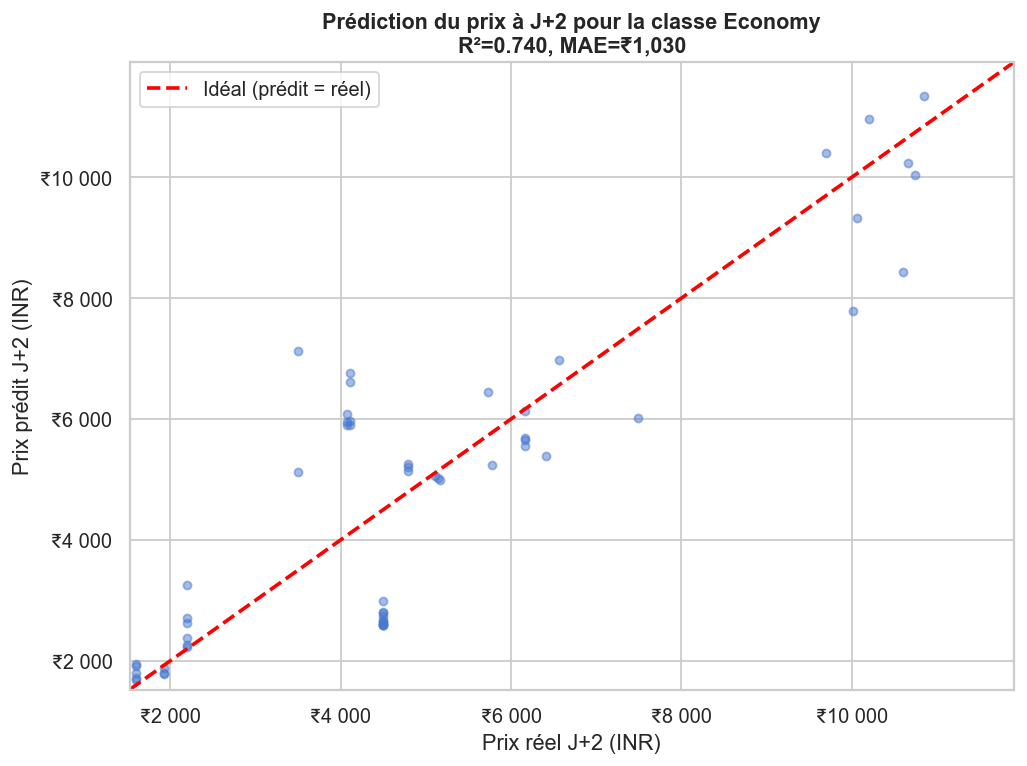

In [73]:
# Graphique prédit vs réel
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.5, s=20, color="#4878CF")
lim = [min(y_test.min(), y_pred.min()) * 0.95, max(y_test.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, "r--", lw=2, label="Idéal (prédit = réel)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_xlabel("Prix réel J+2 (INR)")
ax.set_ylabel("Prix prédit J+2 (INR)")
ax.set_title(f"Prédiction du prix à J+2 pour la classe Economy\nR²={r2_score(y_test, y_pred):.3f}, MAE=₹{mean_absolute_error(y_test, y_pred):,.0f}",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

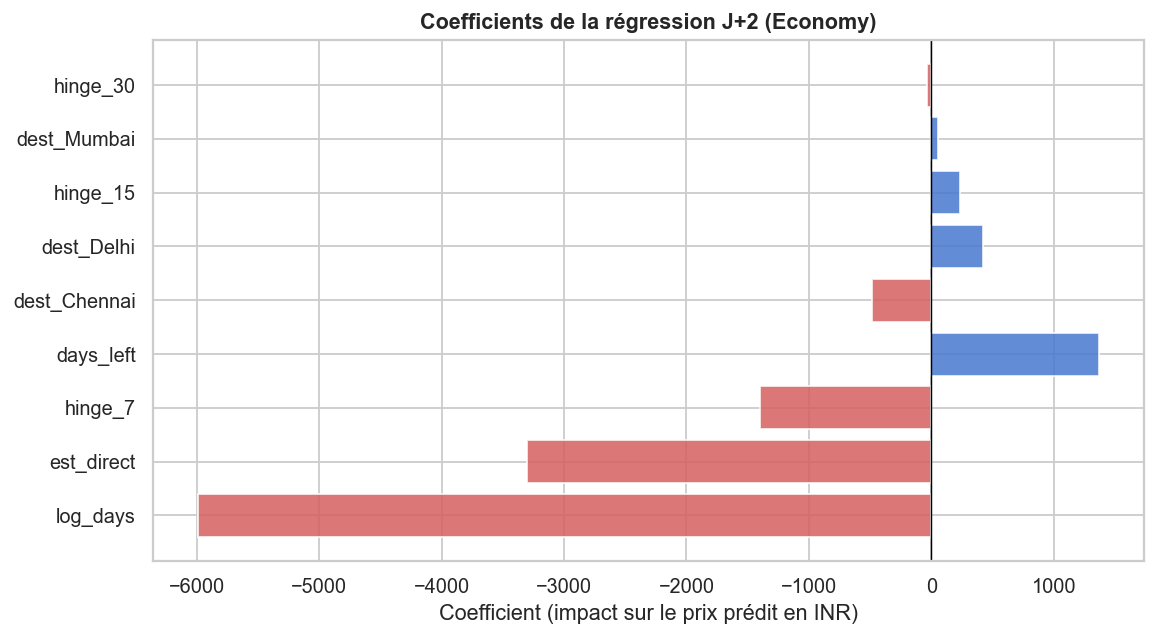

In [74]:
# Coefficients du modèle
coef_df = pd.DataFrame({"Feature": feat_cols, "Coef": model_reg.coef_})
coef_df = coef_df.reindex(coef_df["Coef"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#D65F5F" if c < 0 else "#4878CF" for c in coef_df["Coef"]]
ax.barh(coef_df["Feature"], coef_df["Coef"], color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Coefficients de la régression J+2 (Economy)", fontweight="bold")
ax.set_xlabel("Coefficient (impact sur le prix prédit en INR)")
plt.tight_layout()
plt.show()

### Simulation : si j'observe aujourd'hui (J=20), quel prix dans 2 jours ?

In [75]:
def predict_price_in_n_days(model, feat_cols, breakpoints, dest, direct, days_now, horizon=2):
    days_target = days_now + horizon  # on se projette dans le futur
    row = {"days_left": days_target, "est_direct": int(direct)}
    for d in DESTINATIONS:
        row[f"dest_{d}"] = int(d == dest)
    for bp in breakpoints:
        row[f"hinge_{bp}"] = max(0, days_target - bp)
    row["log_days"] = np.log1p(days_target)

    X_sim = pd.DataFrame([row])[feat_cols]
    return model.predict(X_sim)[0]

# Exemple : Bangalore → Delhi, vol direct, j'observe à J=20 (20 jours avant départ)
for dest in DESTINATIONS:
    for direct, lab in [(1, "Direct"), (0, "1 escale")]:
        prix = predict_price_in_n_days(model_reg, feat_cols, BREAKPOINTS, dest, direct, days_now=20, horizon=2)
        print(f"Bangalore → {dest} | {lab:<10} | J=20, prix prédit dans 2j (J=18) : ₹{prix:,.0f}")
    print()

Bangalore → Chennai | Direct     | J=20, prix prédit dans 2j (J=18) : ₹1,938
Bangalore → Chennai | 1 escale   | J=20, prix prédit dans 2j (J=18) : ₹5,244

Bangalore → Mumbai | Direct     | J=20, prix prédit dans 2j (J=18) : ₹2,474
Bangalore → Mumbai | 1 escale   | J=20, prix prédit dans 2j (J=18) : ₹5,780

Bangalore → Delhi | Direct     | J=20, prix prédit dans 2j (J=18) : ₹2,842
Bangalore → Delhi | 1 escale   | J=20, prix prédit dans 2j (J=18) : ₹6,148



### Cross-validation (k-fold)

On évalue le modèle de manière plus robuste avec une validation croisée k=5.
Cela évite le biais lié à un seul split train/test.

R²  par fold : [0.7404 0.7824 0.6299 0.7836 0.7057]
R²  moyen    : 0.7284  (±0.0572)

MAE par fold : [1030.  882. 1131. 1014. 1225.]
MAE moyenne  : ₹1,057  (±₹116)


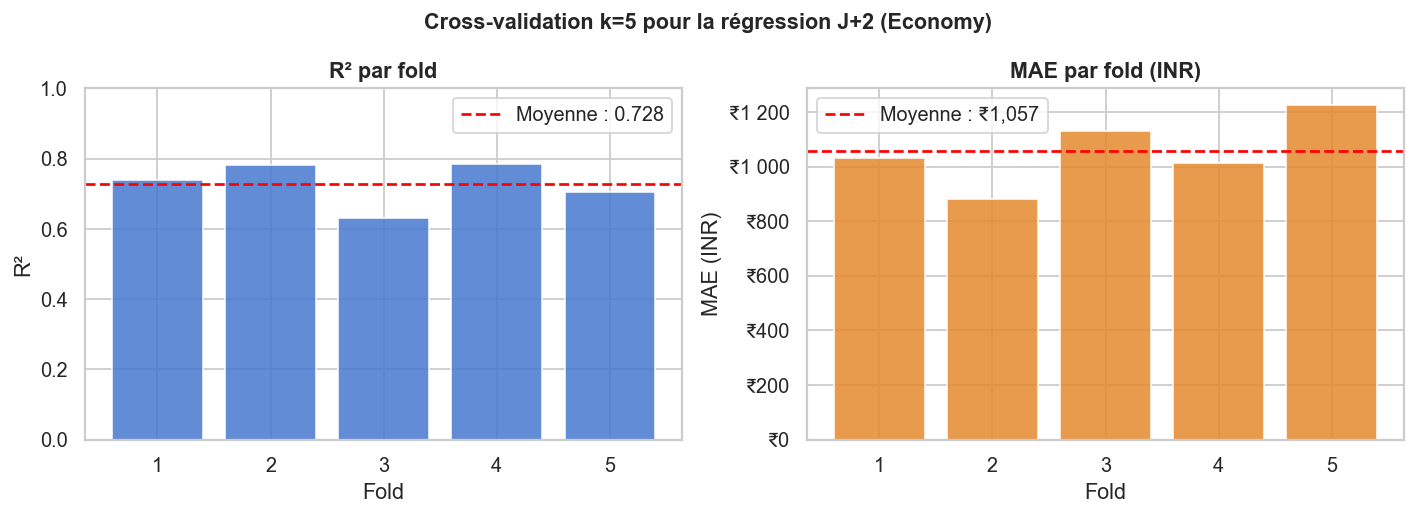

In [76]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R² en cross-val
cv_r2  = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
# MAE en cross-val (scorer retourne des valeurs négatives, on inverse)
cv_mae = -cross_val_score(LinearRegression(), X, y, cv=kf, scoring="neg_mean_absolute_error")

print(f"R²  par fold : {cv_r2.round(4)}")
print(f"R²  moyen    : {cv_r2.mean():.4f}  (±{cv_r2.std():.4f})")
print()
print(f"MAE par fold : {cv_mae.round(0)}")
print(f"MAE moyenne  : ₹{cv_mae.mean():,.0f}  (±₹{cv_mae.std():,.0f})")

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, 6), cv_r2, color="#4878CF", alpha=0.85, edgecolor="white")
axes[0].axhline(cv_r2.mean(), color="red", ls="--", lw=1.5, label=f"Moyenne : {cv_r2.mean():.3f}")
axes[0].set_title("R² par fold", fontweight="bold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(range(1, 6), cv_mae, color="#E68A2E", alpha=0.85, edgecolor="white")
axes[1].axhline(cv_mae.mean(), color="red", ls="--", lw=1.5, label=f"Moyenne : ₹{cv_mae.mean():,.0f}")
axes[1].set_title("MAE par fold (INR)", fontweight="bold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("MAE (INR)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
axes[1].legend()

fig.suptitle("Cross-validation k=5 pour la régression J+2 (Economy)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()